**Table of contents**<a id='toc0_'></a>    
- [Creating a Dataframe of the Crops that Drain into our Sites](#toc1_)    
  - [Header](#toc1_1_)    
  - [Libraries](#toc1_2_)    
  - [Global Variables](#toc1_3_)    
  - [Loading and Examining Data.](#toc1_4_)    
  - [Calculating DEM Flow Data](#toc1_5_)    
  - [Examining our River Network](#toc1_6_)    
  - [Calculating Catchment Mask](#toc1_7_)    
  - [Projecting Mask onto CDL](#toc1_8_)    
  - [Compileing Final CSV (korbin_hydrologyData_2026)](#toc1_9_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[Creating a Dataframe of the Crops that Drain into our Sites](#toc0_)

## <a id='toc1_1_'></a>[Header](#toc0_)

``` python 
# ============================================================
# program:      create_runoff_df.ipynb
#
# purpose:      Delineate watershed catchments for fish survey
#               sites and quantify the upstream crop and land-cover
#                contributing runoff to each site.
#
# usage:        Run interactively in Jupyter Notebook. Requires:
#
#                   - seth_ecoRegionData_2025.csv
#                   - USDA_NASS_CDL_Code_Spreadsheet.csv
#                   - korbin_cdl_2025.tif
#                   - korbin_DEM_USGS10m.tif
#
#               Intermediate watershed products and final site-
#               level hydrology metrics are generated throughout
#               the workflow.
#
# notes:        (1) Uses PySheds D8 routing for hydrologic analysis.
#               (2) Generates flow accumulation and watershed
#                   catchment rasters from a conditioned DEM.
#               (3) Reprojects catchments onto USDA CDL land-cover
#                   data to quantify watershed crop composition.
#               (4) Produces watershed-scale land-use and runoff
#                   metrics for downstream ecological analyses.
#
# date:         07/20/2026
# programmer:   Korbin L. Brashears (KLB)
#
# ============================================================
```

## <a id='toc1_2_'></a>[Libraries](#toc0_)

In [ ]:
# !!!!!!!!!!!!!!!!!!!!!!!!!! IMPORTANT !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!! #
#
# This workflow relies on several geospatial libraries that may cause
# dependency conflicts if installed into a base Conda environment.
# It is strongly recommended to create a dedicated environment:
#
#     conda create -n fishEnv python=3.11 -y
#     conda activate fishEnv
#     conda install -c conda-forge pandas matplotlib "numpy<2.0" "scipy<1.14" pysheds pyproj rioxarray xarray ipynbname rasterio -y
#
# Python 3.11 is recommended because PySheds is not fully compatible
# with newer versions of the scientific Python ecosystem.
#
# NumPy should remain below 2.0 due to compatibility issues with
# PySheds and the removal of legacy functionality relied upon by
# older geospatial packages.
#
# SciPy should remain below 1.14 to avoid dependency conflicts with
# the NumPy 1.x ecosystem required by PySheds.
#
# If running in Jupyter Notebook and a kernel is unavailable:
#
#     conda install ipykernel -y
#
# !!!!!!!!!!!!!!!!!!!!!!!!!! IMPORTANT !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!! #

# Importing Data Analysis Libraries
import pandas as pd
import numpy as np

# Compatibility patch for older PySheds versions
if not hasattr(np, "in1d"):
    np.in1d = np.isin

# Importing Visualization Libraries
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm 

# Importing Geospatial Libraries
from pysheds.grid import Grid
from pyproj import Transformer
import rioxarray
import rasterio
from rasterio.enums import Resampling

# Importing Custom Plotting Libraries
from functions import label_plot_edges as lpe

CRSError: Invalid projection: epsg:4326: (Internal Proj Error: proj_create: no database context specified)

## <a id='toc1_3_'></a>[Global Variables](#toc0_)

In [ ]:
#==============================================================================
# File Paths Configuration
#==============================================================================

# 1. Input Reference Tables (CSV)
S_ERD_P = r"../data/seth_ecoRegionData_2025.csv"
C_CODES_P = r"../data/kbrashears_runoff/USDA_NASS_CDL_Code_Spreadsheet.csv"

# 2. Raw Source Rasters (Original Context Files)
CDL_P = r"../data/kbrashears_runoff/korbin_cdl_2025.tif"
DEM_P = r"../data/kbrashears_runoff/korbin_DEM_USGS10m.tif"

# 3. Intermediate & Processed Topography
R_DEM_P = r"../data/kbrashears_runoff/korbin_DEM_resolved_5070.tif"

# 4. Computed Hydrological Network Rasters
FDIR_P  = r"../data/kbrashears_runoff/korbin_flow_dir.tif"
FACC_P  = r"../data/kbrashears_runoff/korbin_flow_acc.tif"
CATCH_P = r"../data/kbrashears_runoff/korbin_catchment_mask.tif"

# 5. Cropped Watershed Analysis Output
C_CDL_P  = r"../data/kbrashears_runoff/korbin_cdl_catchment_cropped.tif"

# 6. Final Compiled Statistical Summary Tables (CSV)
K_HD_P  = r"../data/kbrashears_runoff/korbin_hydrologyData_2026.csv"



## <a id='toc1_4_'></a>[Loading and Examining Data.](#toc0_)

In [ ]:
#==========================================
# Pandas Read CSV's
#==========================================

s_erd = pd.read_csv(S_ERD_P)
c_codes_df = pd.read_csv(C_CODES_P)

#==========================================
# Rioxarray Read Tif's
#==========================================

cdl_xr = rioxarray.open_rasterio(CDL_P)
dem_xr = rioxarray.open_rasterio(DEM_P)

> Examining our TIF data.

In [ ]:
print("==================================== CDL ======================================================")

# 1. Print the Coordinate Reference System (CRS)
print("--- Projection Details ---")
print("Full CRS object:", cdl_xr.rio.crs)
print("EPSG Code:", cdl_xr.rio.crs.to_epsg())  # Returns None if it is a custom projection

print("\n--- Null / NoData Values ---")
print("Original File NoData Value:", cdl_xr.rio.nodata)

# 2. Print Dimensions and Spatial Resolution
print("\n--- Array Dimensions & Resolution ---")
print("Dimensions:", cdl_xr.sizes)            # Displays band, y, x lengths
print("Pixel Size (Res):", cdl_xr.rio.resolution())  # Returns (x_resolution, y_resolution)

print("\n==================================== DEM ======================================================")

# 1. Print the Coordinate Reference System (CRS)
print("--- Projection Details ---")
print("Full CRS object:", dem_xr.rio.crs)
print("EPSG Code:", dem_xr.rio.crs.to_epsg())  # Returns None if it is a custom projection

print("\n--- Null / NoData Values ---")
print("Original File NoData Value:", dem_xr.rio.nodata)

# 2. Print Dimensions and Spatial Resolution
print("\n--- Array Dimensions & Resolution ---")
print("Dimensions:", dem_xr.sizes)            # Displays band, y, x lengths
print("Pixel Size (Res):", dem_xr.rio.resolution())  # Returns (x_resolution, y_resolution)

==================================== CDL ======================================================
--- Projection Details ---
Full CRS object: EPSG:5070
EPSG Code: 5070

--- Null / NoData Values ---
Original File NoData Value: None

--- Array Dimensions & Resolution ---
Dimensions: Frozen({'band': 1, 'y': 13609, 'x': 25371})
Pixel Size (Res): (10.0, -10.0)

==================================== DEM ======================================================
--- Projection Details ---
Full CRS object: EPSG:4269
EPSG Code: 4269

--- Null / NoData Values ---
Original File NoData Value: -999999.0

--- Array Dimensions & Resolution ---
Dimensions: Frozen({'band': 1, 'y': 13009, 'x': 29991})
Pixel Size (Res): (9.259260000000115e-05, -9.259259999999984e-05)


> Next we will take a look at all of the unique crop codes in our *cdl_xt*.

In [ ]:
target_codes = np.unique(cdl_xr.values)
target_codes = target_codes[~np.isnan(target_codes)]

print(target_codes)
print(f"Number of Unique Crops: {len(target_codes)}")

[  1   2   3   4   5   6  10  12  21  24  26  27  28  29  36  37  44  57
  59  61  69  74 111 121 122 123 124 131 141 142 143 152 176 190 195 205
 224 225 226 236 238]
Number of Unique Crops: 41


> Creating a dict that uses the actual crop names.

In [ ]:
# 3. Filter and build the dictionary dynamically
crop_dict = (
    c_codes_df[c_codes_df['Codes'].isin(target_codes)]
    .set_index('Codes')['Class_Names']
    .to_dict()
)

print(crop_dict)

{1: 'Corn', 2: 'Cotton', 3: 'Rice', 4: 'Sorghum', 5: 'Soybeans', 6: 'Sunflower', 10: 'Peanuts', 12: 'Sweet Corn', 21: 'Barley', 24: 'Winter Wheat', 26: 'Dbl Crop WinWht/Soybeans', 27: 'Rye', 28: 'Oats', 29: 'Millet', 36: 'Alfalfa', 37: 'Other Hay/Non Alfalfa', 44: 'Other Crops', 57: 'Herbs', 59: 'Sod/Grass Seed', 61: 'Fallow/Idle Cropland', 69: 'Grapes', 74: 'Pecans', 111: 'Open Water', 121: 'Developed/Open Space', 122: 'Developed/Low Intensity', 123: 'Developed/Med Intensity', 124: 'Developed/High Intensity', 131: 'Barren', 141: 'Deciduous Forest', 142: 'Evergreen Forest', 143: 'Mixed Forest', 152: 'Shrubland', 176: 'Grass/Pasture', 190: 'Woody Wetlands', 195: 'Herbaceous Wetlands', 205: 'Triticale', 224: 'Vetch', 225: 'Dbl Crop WinWht/Corn', 226: 'Dbl Crop Oats/Corn', 236: 'Dbl Crop WinWht/Sorghum', 238: 'Dbl Crop WinWht/Cotton'}


## <a id='toc1_5_'></a>[Calculating DEM Flow Data](#toc0_)

> Now we want to fill our DEM using the D8 method using pyshed.

> **!! NOTE !!**
>
> If the following files are already present in the root folder, then you may 
>
> Skip to cell: *Loading Precomputed Flow Data*
>
> Precomputed Files:
> * FDIR_P / Flow Direction:
> ** *data/kbrashears_runoff/korbin_flow_dir.tif*
> * FACC_P / Flow Accumulation:
> ** *data/kbrashears_runoff/korbin_flow_acc.tif*
> * R_DEM_P / Resolved DEM:
> ** *data/kbrashears_runoff/korbin_DEM_resolved_5070.tif*

In [ ]:

#========================================================#
#          PRECOMPUTING AND SAVING FLOW DATA             #
#========================================================#

# Initializing a Grid obj with the shape of our DEM.
print('[1/7]: Initializing Grid and Reading DEM...')
grid = Grid.from_raster(DEM_P)

# Reading our DEM information into our Grid.
dem = grid.read_raster(DEM_P, nodata=-999999.0)

print('[2/7]: Resolving NoData...')
dem = dem.astype(np.float64)

# CRITICAL FIX 3: Convert the background -999999.0 markers to np.nan INSIDE PySheds memory.
# PySheds requires its background padding to be np.nan during routing so it ignores them.
dem[dem == grid.nodata] = np.nan

         #N    NE    E    SE    S    SW    W    NW
dirmap = (64,  128,  1,   2,    4,   8,    16,  32)

print('[3/7]: Filling Pits...')
fld_dem = grid.fill_pits(dem)

print('[4/7]: Filling Depressions...')
inf_dem = grid.fill_depressions(fld_dem)

print('[5/7]: Resolving Flats...')
res_dem = grid.resolve_flats(inf_dem)

print('[6/7]: Calculating Flow Direction...')
fdir = grid.flowdir(res_dem, dirmap=dirmap, routing='d8')

print('[7/7]: Calculating Accumulation...')
acc = grid.accumulation(fdir, dirmap=dirmap)

# Save outputs to your dedicated file paths
print("Saving computed watershed layers...")
grid.to_raster(res_dem, R_DEM_P)
grid.to_raster(fdir, FDIR_P)
grid.to_raster(acc, FACC_P)

print("Successfully completed all steps and saved files!")

[1/7]: Initializing Grid and Reading DEM...
[2/7]: Resolving NoData...
[3/7]: Filling Pits...
[4/7]: Filling Depressions...
[5/7]: Resolving Flats...
[6/7]: Calculating Flow Direction...
[7/7]: Calculating Accumulation...
Saving computed watershed layers...
Successfully completed all steps and saved files!


> Plotting results

Generating plots...


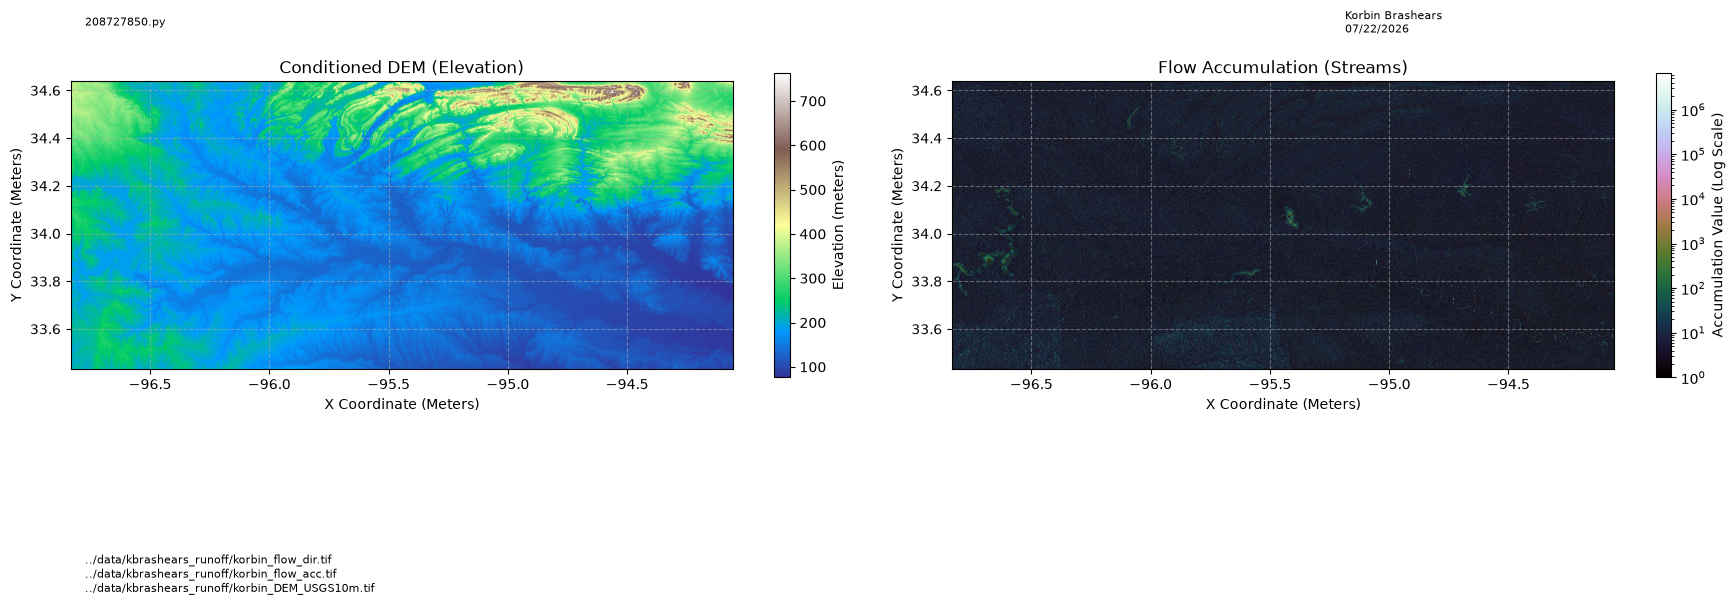

In [ ]:
print("Generating plots...")

# Create a 1-row, 2-column figure layout
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# 1. Plot the Conditioned DEM (Elevation Map)
im1 = ax[0].imshow(res_dem, cmap='terrain', extent=grid.extent)
ax[0].set_title('Conditioned DEM (Elevation)')
fig.colorbar(im1, ax=ax[0], label='Elevation (meters)', shrink=0.7)
# Plot your pour-point (outlet) as a red dot

# 2. Plot Flow Accumulation (Using a Log Scale to reveal streams)
# We add +1 so log(0) doesn't cause a mathematical error
im2 = ax[1].imshow(acc + 1, cmap='cubehelix', norm=LogNorm(vmin=1, vmax=acc.max()), extent=grid.extent)
ax[1].set_title('Flow Accumulation (Streams)')
fig.colorbar(im2, ax=ax[1], label='Accumulation Value (Log Scale)', shrink=0.7)

# Clean up layout formatting
for a in ax:
    a.set_xlabel('X Coordinate (Meters)')
    a.set_ylabel('Y Coordinate (Meters)')
    a.grid(True, linestyle='--', alpha=0.5)
 
plt.tight_layout()

lpe(                                      # Calling the lpe to label the edges of the plot.
    author_names="Korbin Brashears", 
    data_filenames=[FDIR_P, FACC_P, DEM_P], 
    fig_filename="../figures/crop_runoff/DEM_flow_data.png",
    save = False                                                        # Change False to True to save the figure.
    )  


> Now we can use our saved masks to run catchments on all of our sites

> **!! NOTE !!**
>
> If the following files are not present in the root folder, then you need to 
>
> Run the above cell: *PRECOMPUTING AND SAVING FLOW DATA*
>
> And don't bother running this cell.
>
> Precomputed Files:
> * FDIR_P / Flow Direction:
> ** *data/kbrashears_runoff/korbin_flow_dir.tif*
> * FACC_P / Flow Accumulation:
> ** *data/kbrashears_runoff/korbin_flow_acc.tif*
> * R_DEM_P / Resolved DEM:
> ** *data/kbrashears_runoff/korbin_DEM_resolved_5070.tif*

In [ ]:
#==============================================#
#           LOADING SAVED FLOW DATA            #
#==============================================#

# From here, we do not need to generate our flow dirrection, accumulation or resolve our DEM.
# If our fdir, acc, and r_dem files already exist in our data folder, we do not need to regenerate them
# and you may skip PRECOMPUTING AND SAVING FLOW DATA.

# If you have already ran the flow calculation cell above this one, then you may skip running this one.

grid = Grid.from_raster(R_DEM_P)

res_dem = grid.read_raster(R_DEM_P)
fdir = grid.read_raster(FDIR_P)
acc = grid.read_raster(FACC_P)

> Examining at our nth percentile flow accumulation to help determine good thresholds for snapping our site coordinates later on.

In [ ]:
# Flatten the array and remove NaN padding spaces to get clean stats
clean_acc = acc[~np.isnan(acc)]

print("==========================================================")
# The minimum value (usually 1, representing headwater pixels)
print(f"Minimum Accumulation Value: {clean_acc.min():,.1f}")

# 90% of the landscape drains fewer cells than this (hills/slopes)
print(f"90th Percentile (Minor Hills) : {np.percentile(clean_acc, 90):,.1f}")

# 99% of the landscape drains fewer cells than this (small creeks/ditches)
print(f"99th Percentile (Local Creeks): {np.percentile(clean_acc, 99):,.1f}")

# 99.5% of the landscape drains fewer cells than this (streams/tributaries)
print(f"99.5th Percentile (Streams)   : {np.percentile(clean_acc, 99.5):,.1f}")

# 99.9% of the landscape drains fewer cells than this (major river trunks)
print(f"99.9th Percentile (Main Rivers): {np.percentile(clean_acc, 99.9):,.1f}")

print(f"Maximum Accumulation Value    : {clean_acc.max():,.1f}")
print("==========================================================")


Minimum Accumulation Value: 1.0
90th Percentile (Minor Hills) : 39.0
99th Percentile (Local Creeks): 4,767.0
99.5th Percentile (Streams)   : 19,210.0
99.9th Percentile (Main Rivers): 230,207.1
Maximum Accumulation Value    : 6,644,922.0


## <a id='toc1_6_'></a>[Examining our River Network](#toc0_)

> Using various accumulation thresholds to examine the resulting river network.

In [ ]:
branches = grid.extract_river_network(fdir=fdir, mask=(acc>1000))

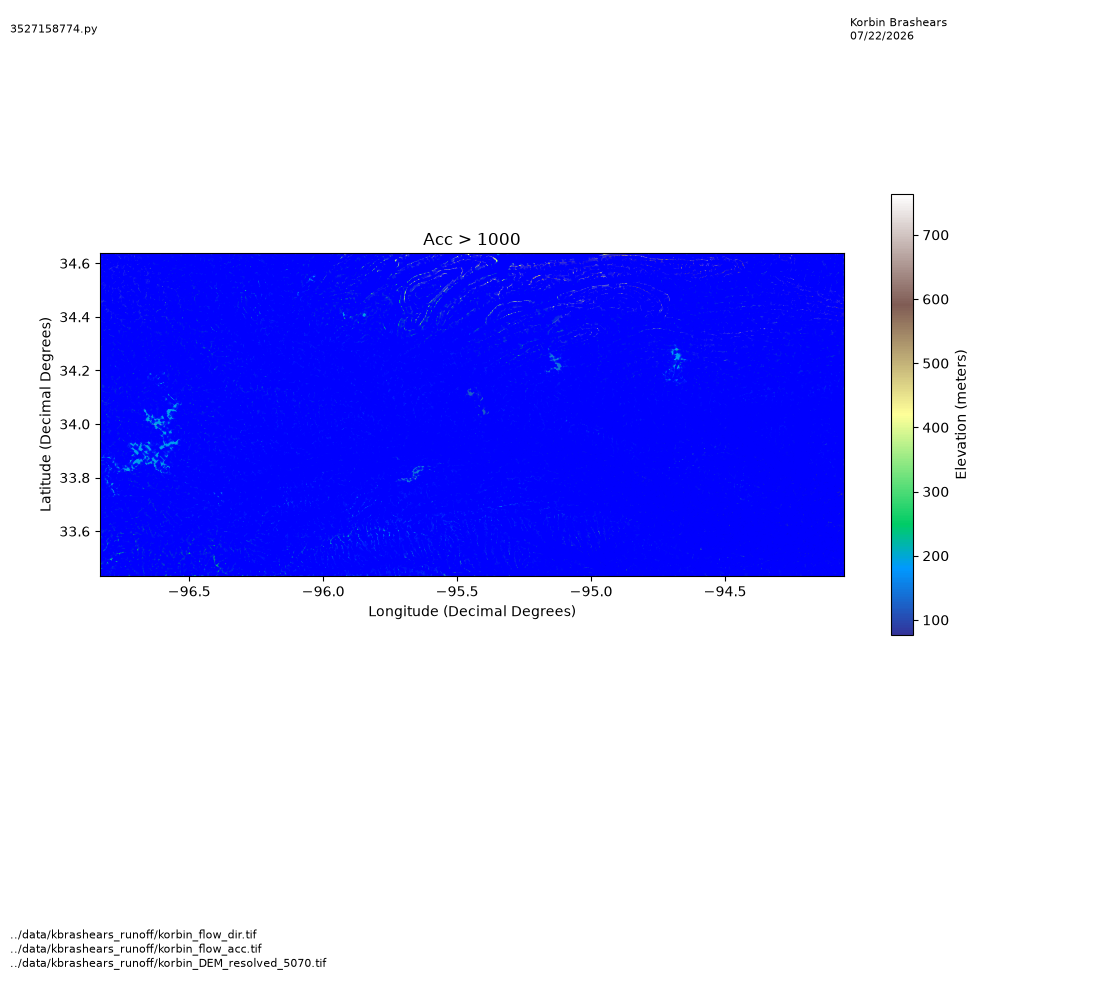

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

im = ax.imshow(res_dem, cmap='terrain', extent=grid.extent)
fig.colorbar(im, ax=ax, label='Elevation (meters)', shrink=0.7)

for feat in branches['features']:
    coords = np.array(feat['geometry']['coordinates'])
    x, y = coords[:,0], coords[:,1]
    ax.plot(x, y, color='blue', linewidth=1.5, alpha=0.8)

ax.set_title('Acc > 1000')
ax.set_xlabel('Longitude (Decimal Degrees)')
ax.set_ylabel('Latitude (Decimal Degrees)')
ax.grid(True, linestyle='--', alpha=0.3)

lpe(                                      # Calling the lpe to label the edges of the plot.
    author_names="Korbin Brashears", 
    data_filenames=[FDIR_P, FACC_P, R_DEM_P], 
    fig_filename="../figures/crop_runoff/river_network_acc1000.png",
    save = False                                                        # Change False to True to save the figure.
    )  

In [ ]:
branches = grid.extract_river_network(fdir=fdir, mask=(acc>5000))

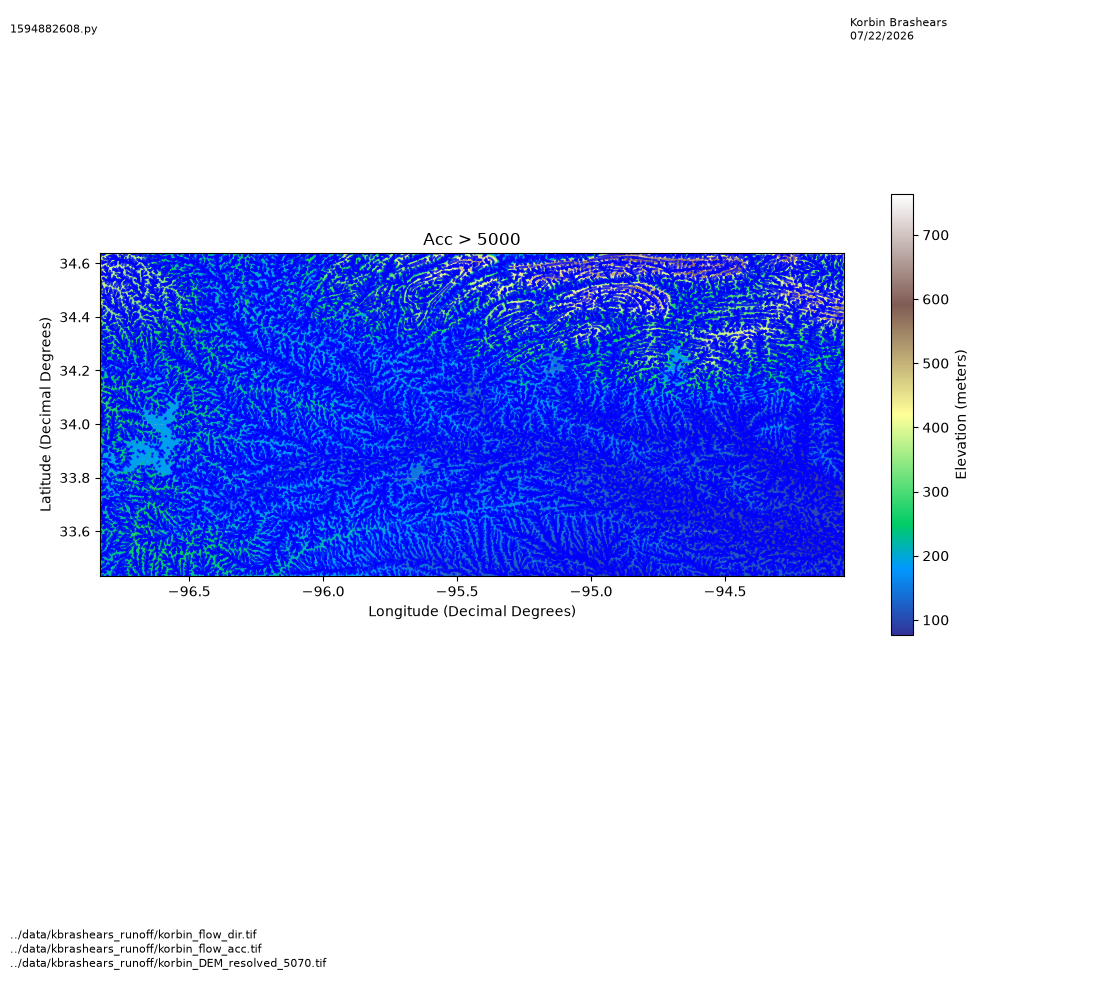

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

im = ax.imshow(res_dem, cmap='terrain', extent=grid.extent)
fig.colorbar(im, ax=ax, label='Elevation (meters)', shrink=0.7)

for feat in branches['features']:
    coords = np.array(feat['geometry']['coordinates'])
    x, y = coords[:,0], coords[:,1]
    ax.plot(x, y, color='blue', linewidth=1.5, alpha=0.8)

ax.set_title('Acc > 5000')
ax.set_xlabel('Longitude (Decimal Degrees)')
ax.set_ylabel('Latitude (Decimal Degrees)')
ax.grid(True, linestyle='--', alpha=0.3)

lpe(                                      # Calling the lpe to label the edges of the plot.
    author_names="Korbin Brashears", 
    data_filenames=[FDIR_P, FACC_P, R_DEM_P], 
    fig_filename="../figures/crop_runoff/river_network_acc5000.png",
    save = False                                                        # Change False to True to save the figure.
    )  

In [ ]:
branches = grid.extract_river_network(fdir=fdir, mask=(acc>15000))

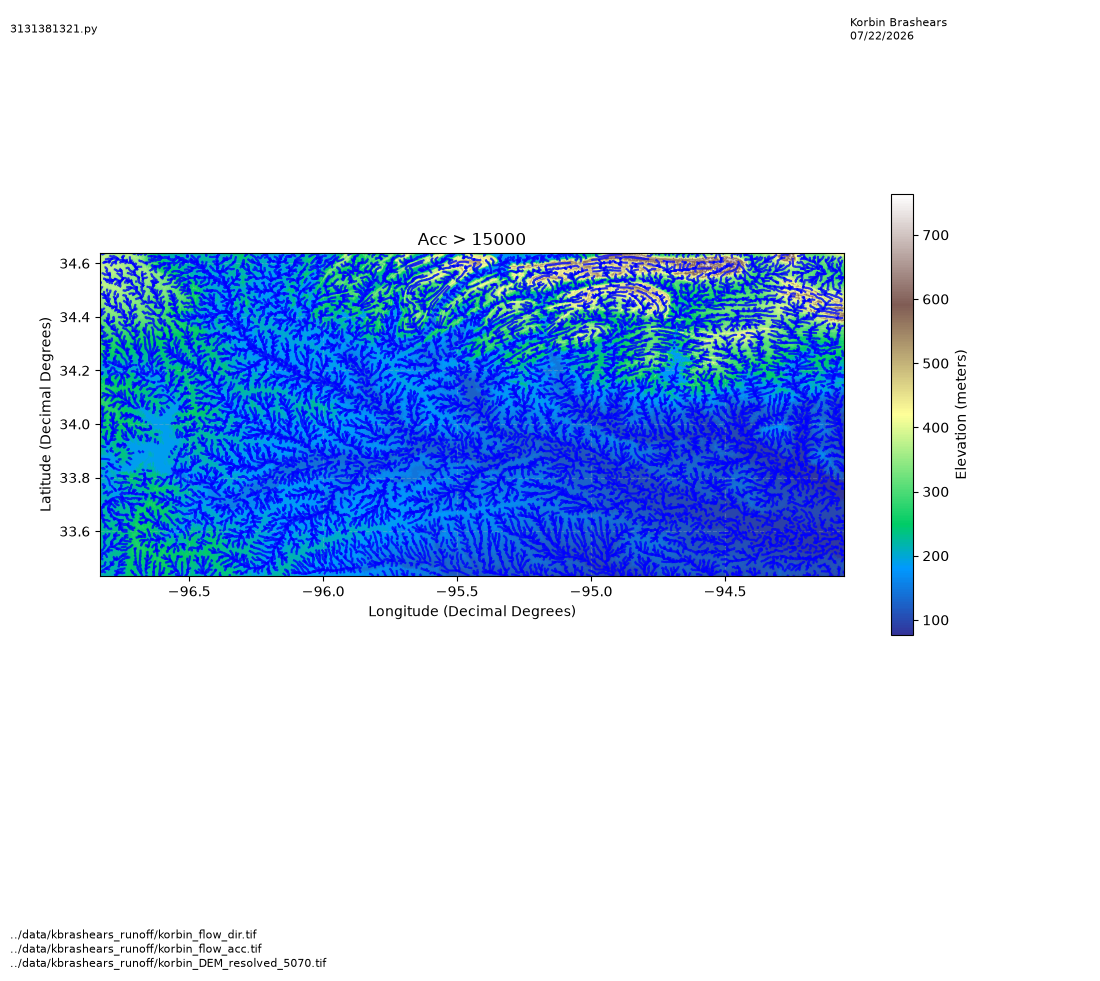

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

im = ax.imshow(res_dem, cmap='terrain', extent=grid.extent)
fig.colorbar(im, ax=ax, label='Elevation (meters)', shrink=0.7)

for feat in branches['features']:
    coords = np.array(feat['geometry']['coordinates'])
    x, y = coords[:,0], coords[:,1]
    ax.plot(x, y, color='blue', linewidth=1.5, alpha=0.8)

ax.set_title('Acc > 15000')
ax.set_xlabel('Longitude (Decimal Degrees)')
ax.set_ylabel('Latitude (Decimal Degrees)')
ax.grid(True, linestyle='--', alpha=0.3)

lpe(                                      # Calling the lpe to label the edges of the plot.
    author_names="Korbin Brashears", 
    data_filenames=[FDIR_P, FACC_P, R_DEM_P], 
    fig_filename="../figures/crop_runoff/river_network_acc15000.png",
    save = False                                                        # Change False to True to save the figure.
    )  

## <a id='toc1_7_'></a>[Calculating Catchment Mask](#toc0_)

> Using our flow data to snap our site points and calculate our catchment mask for our sites.

[1/3]: Extracting coordinate arrays from EcoRegion Data...
[2/3]: Starting native processing loop for 46 watershed sites...
[3/3]: Generating final geographic catchment figures...


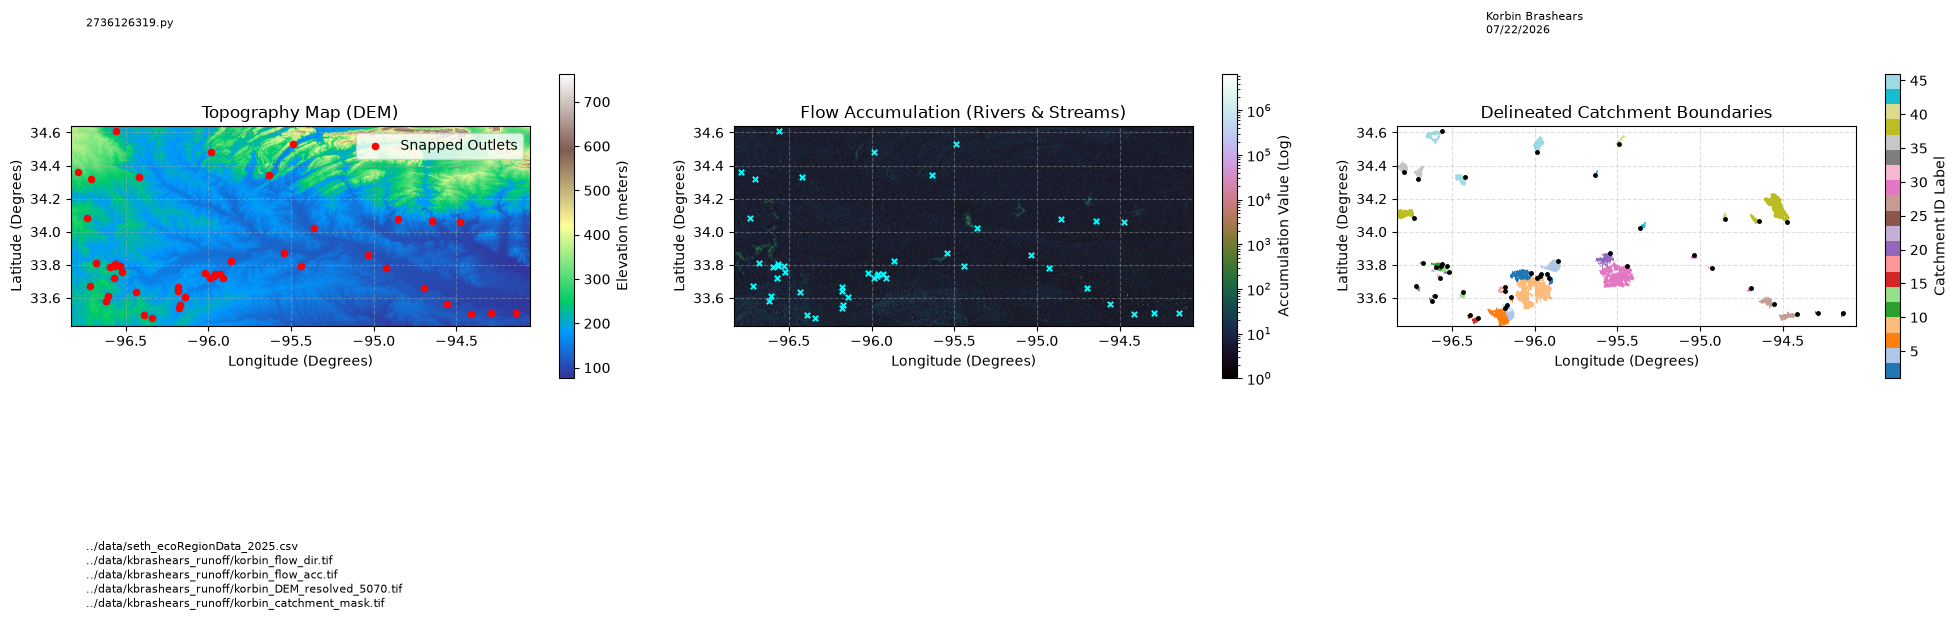

In [ ]:
# ==============================================================================
# Part 2: Multi-Point Catchment Delineation Loop
# ==============================================================================
print('[1/3]: Extracting coordinate arrays from EcoRegion Data...')
lons = s_erd['Long'].values
lats = s_erd['Lat'].values

# Initialize your combined catchment mask array
combined_catchments = np.zeros(grid.shape, dtype=np.int32)
snapped_lon_list, snapped_lat_list = [], []

# FIX 2: Lower the threshold to 500 to catch stable local streams for all points
stream_mask = (acc > 15000)

print(f"[2/3]: Starting native processing loop for {len(lons)} watershed sites...")
for idx, (lon, lat) in enumerate(zip(lons, lats), start=1):
    try:
        # Both raster and dataframe are already in degrees
        x_native, y_native = lon, lat
        
        # Look up to ~5 km away in degree space to hit a verified stream channel
        x_snap, y_snap = grid.snap_to_mask(stream_mask, (x_native, y_native), max_dist=0.05)
        
        snapped_lon_list.append(x_snap)
        snapped_lat_list.append(y_snap)
        
        # Generate the standalone catchment mask array
        single_catch = grid.catchment(x=x_snap, y=y_snap, fdir=fdir, xytype='coordinate', inplace=False)
        combined_catchments[single_catch.astype(bool)] = idx
        
    except Exception as e:
        print(f"Warning: Index {idx} failed to process natively: {e}")
        snapped_lon_list.append(lon)
        snapped_lat_list.append(lat)

# ==============================================================================
# Part 3: Figure Layout Plotting (Fixed Axis Error)
# ==============================================================================
print("[3/3]: Generating final geographic catchment figures...")
fig, ax = plt.subplots(1, 3, figsize=(20, 6))

# Panel 1: Conditioned DEM Elevation Map
im1 = ax[0].imshow(res_dem, cmap='terrain', extent=grid.extent)
ax[0].set_title('Topography Map (DEM)')
fig.colorbar(im1, ax=ax[0], label='Elevation (meters)', shrink=0.7)
ax[0].scatter(snapped_lon_list, snapped_lat_list, color='red', marker='o', s=20, label='Snapped Outlets', zorder=5)
ax[0].legend()

# Panel 2: Hydrographic Channel Networks
im2 = ax[1].imshow(acc + 1, cmap='cubehelix', norm=LogNorm(vmin=1, vmax=acc.max()), extent=grid.extent)
ax[1].set_title('Flow Accumulation (Rivers & Streams)')
fig.colorbar(im2, ax=ax[1], label='Accumulation Value (Log)', shrink=0.7)
ax[1].scatter(snapped_lon_list, snapped_lat_list, color='cyan', marker='x', s=15, zorder=5)

# Panel 3: Multi-Label Watershed Catchments Map
plot_catchments = np.where(combined_catchments > 0, combined_catchments, np.nan)
im3 = ax[2].imshow(plot_catchments, cmap='tab20', extent=grid.extent)
ax[2].set_title('Delineated Catchment Boundaries')
fig.colorbar(im3, ax=ax[2], label='Catchment ID Label', shrink=0.7)
ax[2].scatter(snapped_lon_list, snapped_lat_list, color='black', marker='.', s=25, zorder=5)

# Clear up axes labels and fix bounds using precise tuple slicing
for a in ax:
    a.set_xlabel('Longitude (Degrees)')
    a.set_ylabel('Latitude (Degrees)')
    # FIX 3: Explicitly slice the extent tuple to prevent ValueError ambiguities
    a.set_xlim(grid.extent[0], grid.extent[1])
    a.set_ylim(grid.extent[2], grid.extent[3])
    a.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()

lpe(                                      # Calling the lpe to label the edges of the plot.
    author_names="Korbin Brashears", 
    data_filenames=[S_ERD_P, FDIR_P, FACC_P, R_DEM_P, CATCH_P], 
    fig_filename="../figures/crop_runoff/flow_dataWCatchMask.png",
    save = False                                                        # Change False to True to save the figure.
    )  

> Saving our catchment mask to CATCH_P.

In [ ]:
# 1. Ensure the data types are formatted correctly
data_to_save = combined_catchments.astype('int32') 

# 2. Extract the actual geographic transform matrix from your active PySheds grid object
# PySheds uses 'grid.affine', but rasterio needs it formatted explicitly as a standard object
grid_transform = grid.affine

with rasterio.open(
    CATCH_P, 'w',
    driver='GTiff',
    height=data_to_save.shape[0],
    width=data_to_save.shape[1],
    count=1,
    dtype=data_to_save.dtype,
    crs='EPSG:4269',         # Set this to match your native DEM (EPSG:4269)
    transform=grid_transform  # CRITICAL FIX: Anchors your pixels to real Lon/Lat coords
) as dst:
    dst.write(data_to_save, 1)

print("Catchment saved perfectly with true spatial anchors! Ready for reprojection later.")


Catchment saved perfectly with true spatial anchors! Ready for reprojection later.


## <a id='toc1_8_'></a>[Projecting Mask onto CDL](#toc0_)

> Projecting our new catchment mask onto our CDL to find crops located in the catchment areas.

[1/3] Reprojecting mask onto the metric CDL layout...
[2/3] Slicing down arrays to your active watershed study area...
[3/3] Transforming survey coordinates and rendering the figure...


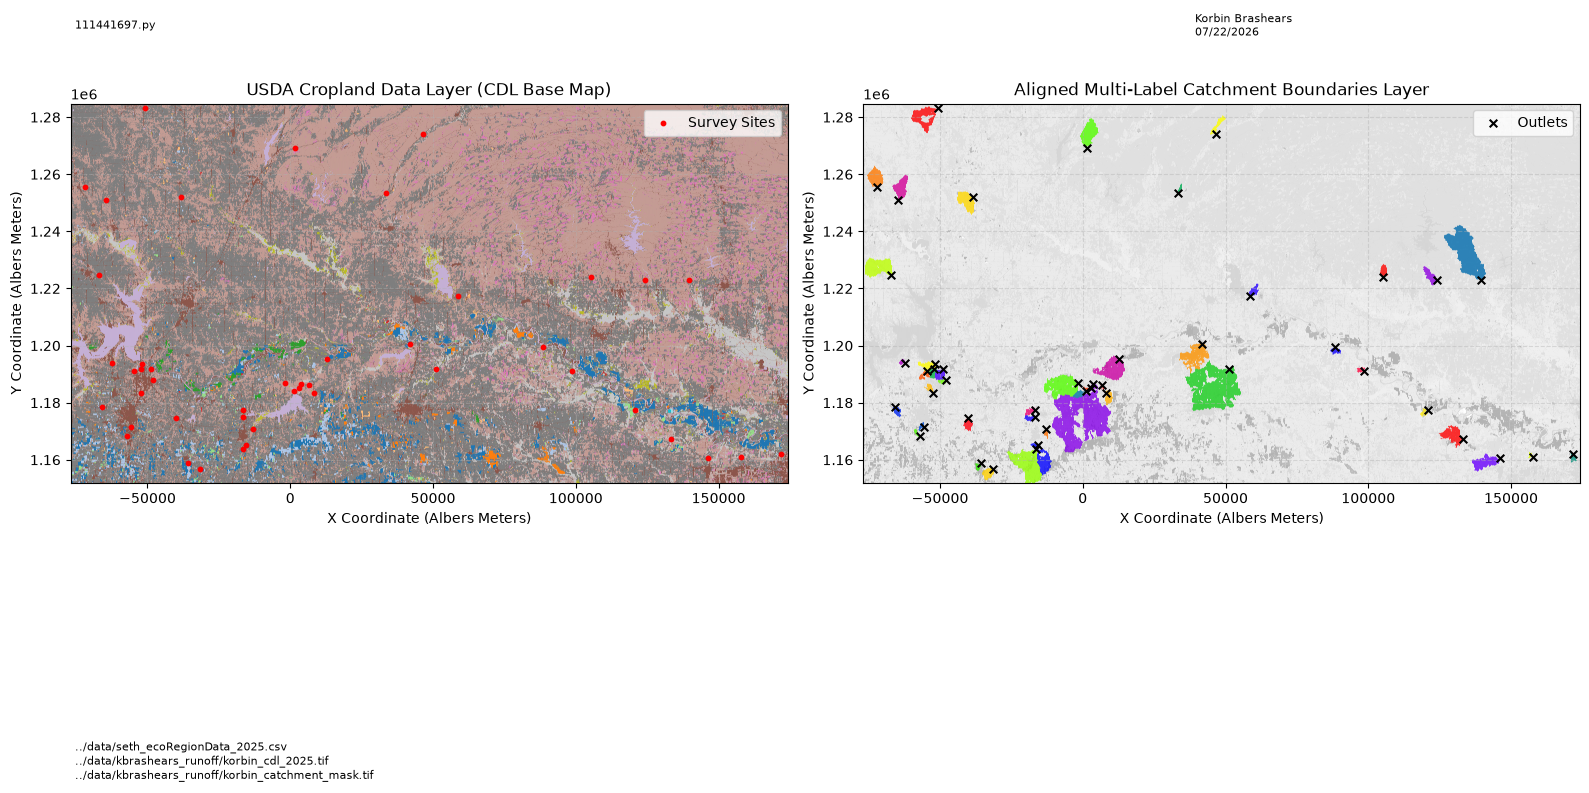

In [ ]:
# 2. Open your newly saved spatial catchment mask (EPSG:4269)
# We open with masked=False to ensure our 0 background values stay flat
catch_native = rioxarray.open_rasterio(CATCH_P, masked=False)

print("[1/3] Reprojecting mask onto the metric CDL layout...")
# 3. Reproject the catchment grid straight onto the CDL layout coordinate system
# Nearest neighbor keeps your catchment site labels (1, 2, 3...) as perfect integers
catch_projected = catch_native.rio.reproject_match(cdl_xr, resampling=Resampling.nearest)

print("[2/3] Slicing down arrays to your active watershed study area...")
# 4. Find the tight pixel box containing your calculated catchments 
# This prevents rendering millions of blank out-of-bounds pixels, saving memory
non_zero_indices = np.where(catch_projected.values[0] > 0)
ymin_idx, ymax_idx = non_zero_indices[0].min(), non_zero_indices[0].max()
xmin_idx, xmax_idx = non_zero_indices[1].min(), non_zero_indices[1].max()

# Add a safe 100-pixel padding boundary around your watersheds for the figure
pad = 100
ymin_idx = max(0, ymin_idx - pad)
ymax_idx = min(catch_projected.shape[1], ymax_idx + pad)
xmin_idx = max(0, xmin_idx - pad)
xmax_idx = min(catch_projected.shape[2], xmax_idx + pad)

# Slice the giant grids down to just this active regional window
cdl_sliced = cdl_xr.values[0, ymin_idx:ymax_idx, xmin_idx:xmax_idx]
catch_sliced = catch_projected.values[0, ymin_idx:ymax_idx, xmin_idx:xmax_idx]

# Dynamically calculate the tight bounding coordinates for Matplotlib's extent
geotransform = catch_projected.rio.transform()
plot_xmin = geotransform[2] + xmin_idx * geotransform[0]
plot_xmax = geotransform[2] + xmax_idx * geotransform[0]
plot_ymax = geotransform[5] + ymin_idx * geotransform[4]  # Y resolution is negative
plot_ymin = geotransform[5] + ymax_idx * geotransform[4]
sliced_extent = [plot_xmin, plot_xmax, plot_ymin, plot_ymax]

print("[3/3] Transforming survey coordinates and rendering the figure...")
# 5. Project your raw CSV degree sites to match the Albers Metric space (EPSG:5070)
lons = s_erd['Long'].values
lats = s_erd['Lat'].values
transformer = Transformer.from_crs("EPSG:4326", "EPSG:5070", always_xy=True)
x_meters, y_meters = transformer.transform(lons, lats)

# ==============================================================================
# Rendering the Overlay Plots
# ==============================================================================
fig, ax = plt.subplots(1, 2, figsize=(16, 8))

# Panel 1: The Cropland Data Layer Base with Site Markers
im1 = ax[0].imshow(cdl_sliced, cmap='tab20', extent=sliced_extent)
ax[0].scatter(x_meters, y_meters, color='red', marker='.', s=40, label='Survey Sites', zorder=5)
ax[0].set_title('USDA Cropland Data Layer (CDL Base Map)')
ax[0].legend(loc='upper right')

# Panel 2: The Aligned Multi-Label Catchment Watershed Boundaries Mask
# Mask out 0 values as NaNs so the CDL base map can show behind it
catch_mask_plot = np.where(catch_sliced > 0, catch_sliced, np.nan)
ax[1].imshow(cdl_sliced, cmap='gray', alpha=0.3, extent=sliced_extent) # Faint terrain background
im2 = ax[1].imshow(catch_mask_plot, cmap='prism', alpha=0.8, extent=sliced_extent)
ax[1].scatter(x_meters, y_meters, color='black', marker='x', s=30, label='Outlets', zorder=5)
ax[1].set_title('Aligned Multi-Label Catchment Boundaries Layer')
ax[1].legend(loc='upper right')

# Set universal grid and coordinate labels for the metric system
for a in ax:
    a.set_xlabel('X Coordinate (Albers Meters)')
    a.set_ylabel('Y Coordinate (Albers Meters)')
    a.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()

lpe(                                      # Calling the lpe to label the edges of the plot.
    author_names="Korbin Brashears", 
    data_filenames=[S_ERD_P, CDL_P, CATCH_P], 
    fig_filename="../figures/crop_runoff/CDL_catchmentMask_sites.png",
    save = False                                                        # Change False to True to save the figure.
    )  

> Extracting unique crop codes present inside the catchment areas

In [ ]:
print("Extracting unique crop codes present inside your catchment areas...")

# 1. Isolate the CDL pixels that fall strictly inside your calculated watersheds
# (where the catchment mask has a value greater than 0)
watershed_crop_pixels = cdl_xr.values[catch_projected.values > 0]

# 2. Extract only the unique crop IDs present in that subset
active_crop_codes = np.unique(watershed_crop_pixels)

# 3. Clean up the array by removing any NaN or NoData values (like 0 or background tags)
active_crop_codes = active_crop_codes[~np.isnan(active_crop_codes)]
active_crop_codes = [int(code) for code in active_crop_codes if code != 0]

print("\n==================================================================")
print(f"Found {len(active_crop_codes)} distinct crop/land cover types inside your watersheds:")
print("==================================================================")

# 4. Loop through and print the active codes alongside their readable dictionary names
for code in sorted(active_crop_codes):
    # Use the crop_dict text name lookup you provided
    crop_name = crop_dict.get(code, f"Unknown/Unmapped Crop (Code {code})")
    print(f"Code {code:3d} : {crop_name}")

print("==================================================================")


Extracting unique crop codes present inside your catchment areas...

Found 31 distinct crop/land cover types inside your watersheds:
Code   1 : Corn
Code   2 : Cotton
Code   3 : Rice
Code   4 : Sorghum
Code   5 : Soybeans
Code   6 : Sunflower
Code  10 : Peanuts
Code  24 : Winter Wheat
Code  26 : Dbl Crop WinWht/Soybeans
Code  27 : Rye
Code  28 : Oats
Code  36 : Alfalfa
Code  37 : Other Hay/Non Alfalfa
Code  59 : Sod/Grass Seed
Code  61 : Fallow/Idle Cropland
Code  74 : Pecans
Code 111 : Open Water
Code 121 : Developed/Open Space
Code 122 : Developed/Low Intensity
Code 123 : Developed/Med Intensity
Code 124 : Developed/High Intensity
Code 131 : Barren
Code 141 : Deciduous Forest
Code 142 : Evergreen Forest
Code 143 : Mixed Forest
Code 152 : Shrubland
Code 176 : Grass/Pasture
Code 190 : Woody Wetlands
Code 195 : Herbaceous Wetlands
Code 236 : Dbl Crop WinWht/Sorghum
Code 238 : Dbl Crop WinWht/Cotton


## <a id='toc1_9_'></a>[Compileing Final CSV (korbin_hydrologyData_2026)](#toc0_)

> Using our catchment mask and cdl data to calculate crop distance and area inside the catchment area for each site.

In [ ]:
import numpy as np
import pandas as pd
from pyproj import Transformer

# ==============================================================================
# Final Normalized Crop Lookup Table Reference Dictionary (User Constraints)
# ==============================================================================
TARGET_CDL_NAMES = {
    1: "Corn",
    2: "Cotton",
    3: "Rice",
    4: "Sorghum",
    5: "Soybeans",
    6: "Sunflower",
    10: "Peanuts",
    24: "WinterWheat",
    26: "WinterWheat_Soybeans",
    27: "Rye",
    28: "Oats",
    36: "Alfalfa",
    37: "OtherHay_NonAlfalfa",
    59: "Sod_Fescue",
    61: "Fallow_IdleCropland",
    74: "Pecans",
    111: "OpenWater",
    121: "Developed_OpenSpace",
    122: "Developed_LowIntensity",
    123: "Developed_MediumIntensity",
    124: "Developed_HighIntensity",
    131: "Barren",
    141: "DeciduousForest",
    142: "Evergreen",
    143: "MixedForest",
    152: "Shrubland",
    176: "Grassland",
    190: "WoodyWetlands",
    195: "hWetlands",
    236: "WinterWheat_Sorghum",
    238: "Barley_Soybeans"
}

# ==============================================================================
# Complete USLE Crop Erosion C-Factors Mapping for All Code Possibilities
# ==============================================================================
C_FACTORS = {
    1: 0.36, 2: 0.34, 3: 0.15, 4: 0.30, 5: 0.32, 6: 0.32, 10: 0.30, 12: 0.25, 
    21: 0.20, 24: 0.25, 26: 0.20, 27: 0.20, 28: 0.20, 29: 0.25, 36: 0.02, 37: 0.04, 
    44: 0.15, 57: 0.10, 59: 0.01, 61: 0.40, 69: 0.12, 74: 0.08, 111: 0.00, 121: 0.01, 
    122: 0.02, 123: 0.05, 124: 0.10, 131: 0.45, 141: 0.003, 142: 0.003, 143: 0.003, 
    152: 0.01, 176: 0.02, 190: 0.001, 195: 0.002, 205: 0.20, 224: 0.05, 225: 0.22, 
    226: 0.22, 236: 0.22, 238: 0.18, 'default': 0.05
}

print("Reading live plotting cache arrays...")
# Ensure 2D handling matching your syntax slice modifications
cdl_matrix = cdl_xr.values[0]          
catch_matrix = catch_projected.values[0] 
geotransform = catch_projected.rio.transform()

# Extract pixel resolution size grid step scale (10.0 meters)
pixel_size = abs(geotransform[0])

# Transform original Lat/Lon points to Albers meters to match pixel row/col lookup bounds
lons = s_erd['Long'].values
lats = s_erd['Lat'].values
transformer = Transformer.from_crs("EPSG:4326", "EPSG:5070", always_xy=True)
x_meters, y_meters = transformer.transform(lons, lats)

k_hd = s_erd.copy()
analysis_records = []

print("Running spatial lookup matrix calculations for all 46 sites...")
for idx in range(1, len(s_erd) + 1):
    # Pinpoint the row and column coordinates of the outlet pixel on the master matrix
    out_x_m = x_meters[idx - 1]
    out_y_m = y_meters[idx - 1]
    
    # Map coordinates safely back to pixel row/column matrix indices
    out_col = int((out_x_m - geotransform[2]) / geotransform[0])
    out_row = int((out_y_m - geotransform[5]) / geotransform[4])
    
    # Isolate pixels inside this specific catchment zone
    site_mask = (catch_matrix == idx)
    
    if not np.any(site_mask):
        base_record = {
            "site_id": idx, "watershed_area_sq_km": 0.0, "potential_erosion": 0.0
        }
        # Force fill targets to 0/NaN if the watershed layer is blank
        for code, name in TARGET_CDL_NAMES.items():
            base_record[f"pc_{name}"] = 0.0
            base_record[f"area_{name}"] = 0.0
            base_record[f"minDist_{name}"] = np.nan
        analysis_records.append(base_record)
        continue
        
    # Get spatial row/col indices for distance tracking
    row_indices, col_indices = np.where(site_mask)
    crops_in_watershed = cdl_matrix[site_mask]
    total_pixels = len(crops_in_watershed)
    
    # Calculate unique crops and their raw frequency counts inside this polygon footprint
    unique_crops, counts = np.unique(crops_in_watershed, return_counts=True)
    crop_counts_dict = dict(zip(unique_crops, counts))
    
    site_record = {
        "site_id": idx,
        "watershed_area_sq_km": round((total_pixels * (pixel_size ** 2)) / 1e6, 4),
        "potential_erosion": 0.0
    }
    
    weighted_erosion_sum = 0.0
    
    # Evaluate every standard target crop classification explicitly requested
    for target_code, target_name in TARGET_CDL_NAMES.items():
        if target_code in crop_counts_dict:
            count = crop_counts_dict[target_code]
            
            # 1. Percentages Metric Column
            pct = (count / total_pixels) * 100
            site_record[f"pc_{target_name}"] = round(pct, 2)
            
            # 2. Area Coverage Metric Column (Square Kilometers)
            area_km2 = (count * (pixel_size ** 2)) / 1e6
            site_record[f"area_{target_name}"] = round(area_km2, 4)
            
            # 3. Minimum Euclidean Distance to Monitoring Outlet (Meters)
            crop_pixel_locs = (crops_in_watershed == target_code)
            crop_rows = row_indices[crop_pixel_locs]
            crop_cols = col_indices[crop_pixel_locs]
            
            row_deltas = crop_rows - out_row
            col_deltas = crop_cols - out_col
            distances_meters = np.sqrt((row_deltas ** 2) + (col_deltas ** 2)) * pixel_size
            
            site_record[f"minDist_{target_name}"] = round(distances_meters.min(), 2)
        else:
            # Explicitly set missing target crops to zero arrays/blank metrics
            site_record[f"pc_{target_name}"] = 0.0
            site_record[f"area_{target_name}"] = 0.0
            site_record[f"minDist_{target_name}"] = np.nan
            
    # Calculate potential erosion index using ALL actual pixels present in watershed
    # This prevents calculations from clipping missing codes
    for actual_code, actual_count in crop_counts_dict.items():
        actual_pct = (actual_count / total_pixels) * 100
        c_val = C_FACTORS.get(int(actual_code), C_FACTORS['default'])
        weighted_erosion_sum += (actual_pct / 100.0) * c_val
        
    site_record["potential_erosion"] = round(weighted_erosion_sum * 100, 4)
    analysis_records.append(site_record)

print("Compiling dataset structure fields...")
analysis_df = pd.DataFrame(analysis_records)

print(f"Merging variables and exporting your clean final CSV file to path: {K_HD_P}")
k_hd['site_id'] = range(1, len(k_hd) + 1)
k_hd_final = pd.merge(k_hd, analysis_df, on='site_id', how='left')

# Write your master dataset file directly to disk catalog path!
k_hd_final.to_csv(K_HD_P, index=False)
print("Pipeline fully completed! Your customized erosion spreadsheet dataset is written and ready.")


Reading live plotting cache arrays...


NameError: name 'cdl_xr' is not defined